In [3]:
import numpy as np

# ── Pretrained checkpoint ─────────────────────────────────────────────────────
CORRELATION         = 0.25
PRETRAIN_CHECKPOINT = f"pretrain_corr_{CORRELATION:.2f}.pth"

# ── Concentration sweep ───────────────────────────────────────────────────────
CONCENTRATIONS = [0.3]#np.linspace(0.1, 0.9, 5).tolist()   # 10 values from 0.05 → 0.95

# ── Finetuning hyperparameters ────────────────────────────────────────────────
FINETUNE_STEPS        = 3_000
FINETUNE_BATCH_SIZE   = 96
FINETUNE_LR           = 1e-5
FINETUNE_MIN_LR       = 1e-7
FINETUNE_WARMUP_RATIO = 0.2
MAX_GRAD_NORM         = 1.0

# ── Logging & evaluation ──────────────────────────────────────────────────────
LOG_INTERVAL          = 200     # keep this reasonable given the sweep cost
METRICS               = ["loss", "answer_acc"]

# ── Gradient / drift probing ──────────────────────────────────────────────────
GRAD_PROBE_BATCH_SIZE = 32

# ── Tasks ─────────────────────────────────────────────────────────────────────
FINETUNE_TASK_NAMES = [
    "count_a",
    "count_b", "count_c",
    "count_aa", "count_bb", "count_cc",
    "index_a",  "index_b",  "index_c",
    "index_aa", "index_bb", "index_cc",
    "token_at_40",
]
SPECIAL_TASK = "count_a"

# ── Eval dataset sizes ────────────────────────────────────────────────────────
VAL_EXAMPLES        = 500
EVAL_PER_OTHER_TASK = 500

# ── Model architecture (must match checkpoint) ────────────────────────────────
MODEL_CFG = dict(
    block_size=512, n_layer=6, n_head=6, n_embd=192,
    embd_pdrop=0.1, resid_pdrop=0.1, attn_pdrop=0.1,
)

# ── PCFG pools ────────────────────────────────────────────────────────────────
POOL_N_CORRELATED   = 10_000
POOL_N_UNCORRELATED = 10_000
CHUNK_SIZE          = 250

# ── Optimizer ─────────────────────────────────────────────────────────────────
OPTIMIZER_CFG = dict(type="AdamW", weight_decay=0.0, betas=[0.9, 0.95], eps=1e-8)

# ── Misc ──────────────────────────────────────────────────────────────────────
SEED   = 42
DEVICE = "auto"

In [4]:
CONCENTRATIONS

[0.3]

In [5]:
import os, math, random, itertools
import torch
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.cm as cm

from config       import CFG
from config_utils import (
    build_optimizer, build_task_registry,
    get_device, get_warmup_steps, set_seed,
)
from mingpt   import GPT, GPTConfig
from pcfg_gen import (
    CharTokenizer, PCFGDataset, PCFGGenerator,
    generate_dataset, build_pools,
)
from train_help import (
    sample_batch, get_cosine_lr,
    _build_val_loaders, _evaluate_loader,
    calculate_answer_accuracy,
)

set_seed(SEED)
device = get_device(DEVICE)
print(f"Device : {device}")
print(f"PyTorch: {torch.__version__}")
print(f"\nConcentrations to sweep ({len(CONCENTRATIONS)}):")
for c in CONCENTRATIONS:
    print(f"  {c:.3f}")

Device : cuda
PyTorch: 2.10.0+cu130

Concentrations to sweep (1):
  0.300


In [6]:
pcfg = PCFGGenerator()

pools = build_pools(
    pcfg_gen       = pcfg,
    n_correlated   = POOL_N_CORRELATED,
    n_uncorrelated = POOL_N_UNCORRELATED,
    chunk_size     = CHUNK_SIZE,
    verbose        = True,
)
print(f"\nPool sizes — correlated: {len(pools['correlated']):,} | "
      f"uncorrelated: {len(pools['uncorrelated']):,}")

Building PCFG pools: 10,000 correlated + 10,000 uncorrelated strings …
  generated 50,000 | correlated 4,573/10,000 (9.1% acceptance)
  generated 100,000 | correlated 9,257/10,000 (9.3% acceptance)
Pools ready — 10,000 correlated, 10,000 uncorrelated from 108,833 total generations (9.2% acceptance rate).

Pool sizes — correlated: 10,000 | uncorrelated: 10,000


In [7]:
tokenizer     = CharTokenizer()
task_registry = build_task_registry(CFG["task_definitions"])

ALL_TASKS   = CFG["task_sets"]["all"]
OTHER_TASKS = [t for t in ALL_TASKS if t not in ("count_a", "count_b")]

MAX_LEN          = CFG["tokenizer"]["max_length"]
MASK_ANSWER_ONLY = CFG["tokenizer"]["mask_answer_only_val"]

print("Generating count_a eval set …")
count_a_examples = generate_dataset(
    n_examples=VAL_EXAMPLES, task_names=["count_a"],
    pcfg_gen=pcfg, task_reg=task_registry, chunk_size=CHUNK_SIZE,
)
print("Generating count_b eval set …")
count_b_examples = generate_dataset(
    n_examples=VAL_EXAMPLES, task_names=["count_b"],
    pcfg_gen=pcfg, task_reg=task_registry, chunk_size=CHUNK_SIZE,
)
print(f"Generating other-task eval sets ({len(OTHER_TASKS)} tasks × {EVAL_PER_OTHER_TASK}) …")
other_examples = []
for t in OTHER_TASKS:
    other_examples += generate_dataset(
        n_examples=EVAL_PER_OTHER_TASK, task_names=[t],
        pcfg_gen=pcfg, task_reg=task_registry, chunk_size=CHUNK_SIZE,
    )

eval_datasets = {
    "count_a":       PCFGDataset(count_a_examples, tokenizer,
                                 max_length=MAX_LEN, mask_answer_only=MASK_ANSWER_ONLY),
    "count_b":       PCFGDataset(count_b_examples, tokenizer,
                                 max_length=MAX_LEN, mask_answer_only=MASK_ANSWER_ONLY),
    "all_other_avg": PCFGDataset(other_examples,   tokenizer,
                                 max_length=MAX_LEN, mask_answer_only=MASK_ANSWER_ONLY),
}
print("\nEval dataset sizes:")
for name, ds in eval_datasets.items():
    print(f"  {name:<18} {len(ds):>6}")

Tokenizer vocabulary size: 267
Generating count_a eval set …
Generating count_b eval set …
Generating other-task eval sets (11 tasks × 500) …

Eval dataset sizes:
  count_a               500
  count_b               500
  all_other_avg        5500


In [8]:
gpt_config = GPTConfig(
    vocab_size  = tokenizer.vocab_size,
    block_size  = MODEL_CFG["block_size"],
    n_layer     = MODEL_CFG["n_layer"],
    n_head      = MODEL_CFG["n_head"],
    n_embd      = MODEL_CFG["n_embd"],
    embd_pdrop  = MODEL_CFG["embd_pdrop"],
    resid_pdrop = MODEL_CFG["resid_pdrop"],
    attn_pdrop  = MODEL_CFG["attn_pdrop"],
)

# Detect layer prefixes once from a temporary model instance
_tmp = GPT(gpt_config)
layer_prefixes = sorted({
    ".".join(n.split(".")[:3])
    for n, _ in _tmp.named_parameters()
    if n.startswith("transformer.h.")
})
del _tmp
layer_labels = [f"L{i}" for i in range(len(layer_prefixes))]
n_layers     = len(layer_prefixes)
print(f"Transformer block layers ({n_layers}): {layer_prefixes}")


def get_layer_grads(model, batch):
    """One forward+backward; returns {layer_prefix: flat grad vector}. No opt step."""
    model.train()
    model.zero_grad()
    _, loss = model(batch["input_ids"].to(device), batch["target_ids"].to(device))
    loss.backward()
    grads = {}
    for prefix in layer_prefixes:
        vecs = [p.grad.detach().cpu().float().flatten()
                for n, p in model.named_parameters()
                if n.startswith(prefix) and p.grad is not None]
        if vecs:
            grads[prefix] = torch.cat(vecs)
    model.zero_grad()
    return grads


def cossim(a, b):
    return (a @ b / (a.norm() * b.norm()).clamp(min=1e-12)).item()


def probe_batch(task_name):
    return sample_batch(
        batch_size=GRAD_PROBE_BATCH_SIZE, task_names=[task_name],
        task_weights=[1.0], pcfg_gen=pcfg, task_reg=task_registry,
        tokenizer=tokenizer, chunk_size=CHUNK_SIZE, mask_answer_only=False,
        data_pools=pools, correlation=CORRELATION,
    )


def compute_grad_and_drift_metrics(model, base_params):
    other_tasks   = [t for t in FINETUNE_TASK_NAMES if t != SPECIAL_TASK]
    special_grads = get_layer_grads(model, probe_batch(SPECIAL_TASK))
    other_grads   = {t: get_layer_grads(model, probe_batch(t)) for t in other_tasks}

    sv_o, o_o, drift = [], [], []
    for prefix in layer_prefixes:
        g_sp       = special_grads.get(prefix)
        other_vecs = [other_grads[t][prefix] for t in other_tasks
                      if prefix in other_grads[t]]

        # special vs mean-other
        if g_sp is not None and other_vecs:
            sv_o.append(cossim(g_sp, torch.stack(other_vecs).mean(0)))
        else:
            sv_o.append(float("nan"))

        # mean pairwise among others
        if len(other_vecs) >= 2:
            pairs = list(itertools.combinations(other_vecs, 2))
            o_o.append(float(np.mean([cossim(a, b) for a, b in pairs])))
        elif len(other_vecs) == 1:
            o_o.append(1.0)
        else:
            o_o.append(float("nan"))

        # weight drift
        diffs = [(p.detach().cpu().float() - base_params[n]).flatten()
                 for n, p in model.named_parameters()
                 if n.startswith(prefix) and n in base_params]
        drift.append(torch.cat(diffs).norm().item() if diffs else float("nan"))

    return sv_o, o_o, drift

number of parameters: 2.82M
Transformer block layers (6): ['transformer.h.0', 'transformer.h.1', 'transformer.h.2', 'transformer.h.3', 'transformer.h.4', 'transformer.h.5']


In [9]:
assert os.path.exists(PRETRAIN_CHECKPOINT), f"Not found: {PRETRAIN_CHECKPOINT}"

# all_histories[concentration] = history dict
all_histories = {}

for conc_idx, concentration in enumerate(CONCENTRATIONS):
    print(f"\n{'='*70}")
    print(f"  Concentration {conc_idx+1}/{len(CONCENTRATIONS)}: {concentration:.3f}")
    print(f"{'='*70}")

    # ── Fresh model from checkpoint ───────────────────────────────────────────
    model = GPT(gpt_config).to(device)
    ckpt  = torch.load(PRETRAIN_CHECKPOINT, map_location=device)
    model.load_state_dict(ckpt["model_state_dict"])

    # Frozen base weights for drift (will be updated at each eval step)
    last_eval_params = {
        name: param.detach().cpu().float().clone()
        for name, param in model.named_parameters()
    }

    # ── Task weights ──────────────────────────────────────────────────────────
    n_other          = len(FINETUNE_TASK_NAMES) - 1
    other_w          = (1.0 - concentration) / n_other
    finetune_weights = [concentration] + [other_w] * n_other

    # ── Optimizer ─────────────────────────────────────────────────────────────
    optimizer    = build_optimizer(model.parameters(), OPTIMIZER_CFG, FINETUNE_LR)
    warmup_steps = get_warmup_steps(FINETUNE_STEPS, warmup_ratio=FINETUNE_WARMUP_RATIO)
    val_loaders  = _build_val_loaders(eval_datasets, FINETUNE_BATCH_SIZE, tokenizer)
    metrics_set  = set(METRICS)

    # ── History ───────────────────────────────────────────────────────────────
    history = {
        "steps"                        : [],
        "train_loss"                   : [],
        "train_answer_acc"             : [],
        "val"                          : {n: {"loss": [], "answer_acc": []}
                                          for n in val_loaders},
        "grad_cossim_special_vs_other" : [],
        "grad_cossim_other_vs_other"   : [],
        "weight_drift"                 : [],
    }

    # ── Training loop ─────────────────────────────────────────────────────────
    log_prefix = f"conc={concentration:.2f}"

    for step in range(1, FINETUNE_STEPS + 1):
        cur_lr = get_cosine_lr(step, FINETUNE_STEPS, FINETUNE_LR,
                               FINETUNE_MIN_LR, warmup_steps)
        for pg in optimizer.param_groups:
            pg["lr"] = cur_lr

        batch = sample_batch(
            batch_size=FINETUNE_BATCH_SIZE, task_names=FINETUNE_TASK_NAMES,
            task_weights=finetune_weights, pcfg_gen=pcfg, task_reg=task_registry,
            tokenizer=tokenizer, chunk_size=CHUNK_SIZE, mask_answer_only=False,
            data_pools=pools, correlation=CORRELATION,
        )

        model.train()
        optimizer.zero_grad()
        logits, loss = model(batch["input_ids"].to(device),
                             batch["target_ids"].to(device))
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), MAX_GRAD_NORM)
        optimizer.step()

        train_acc, _ = calculate_answer_accuracy(
            logits, batch["target_ids"].to(device), batch["answer_positions"])

        if step % LOG_INTERVAL == 0:
            history["steps"].append(step)
            history["train_loss"].append(loss.item())
            history["train_answer_acc"].append(train_acc)

            log_parts = [f"{log_prefix} step {step}/{FINETUNE_STEPS}",
                         f"loss={loss.item():.4f}", f"acc={train_acc:.3f}",
                         f"lr={cur_lr:.2e}"]

            for name, loader in val_loaders.items():
                v_loss, v_acc = _evaluate_loader(model, loader, device, metrics_set)
                history["val"][name]["loss"].append(v_loss)
                history["val"][name]["answer_acc"].append(v_acc)
                log_parts += [f"{name}_acc={v_acc:.3f}"]

            sv_o, o_o, drift = compute_grad_and_drift_metrics(model, last_eval_params)
            history["grad_cossim_special_vs_other"].append(sv_o)
            history["grad_cossim_other_vs_other"].append(o_o)
            history["weight_drift"].append(drift)
            
            # Update last_eval_params to current model state for next eval
            last_eval_params = {
                name: param.detach().cpu().float().clone()
                for name, param in model.named_parameters()
            }

            log_parts += [
                f"grad_sim(spc↔other)={np.nanmean(sv_o):.3f}",
                f"grad_sim(o↔o)={np.nanmean(o_o):.3f}",
                f"drift={np.nanmean(drift):.4f}",
            ]
            print(" | ".join(log_parts))

    all_histories[concentration] = history
    print(f"  Done with concentration={concentration:.3f}")

print("\n\nSweep complete!")


  Concentration 1/1: 0.300
number of parameters: 2.82M
conc=0.30 step 200/3000 | loss=0.4541 | acc=0.708 | lr=3.33e-06 | count_a_acc=0.374 | count_b_acc=1.000 | all_other_avg_acc=0.992 | grad_sim(spc↔other)=-0.083 | grad_sim(o↔o)=0.017 | drift=0.0916
conc=0.30 step 400/3000 | loss=0.4466 | acc=0.854 | lr=6.67e-06 | count_a_acc=0.430 | count_b_acc=1.000 | all_other_avg_acc=0.992 | grad_sim(spc↔other)=0.044 | grad_sim(o↔o)=0.015 | drift=0.2593
conc=0.30 step 600/3000 | loss=0.4409 | acc=0.823 | lr=1.00e-05 | count_a_acc=0.606 | count_b_acc=1.000 | all_other_avg_acc=0.991 | grad_sim(spc↔other)=0.001 | grad_sim(o↔o)=-0.003 | drift=0.3935
conc=0.30 step 800/3000 | loss=0.4392 | acc=0.906 | lr=9.83e-06 | count_a_acc=0.858 | count_b_acc=1.000 | all_other_avg_acc=0.990 | grad_sim(spc↔other)=0.026 | grad_sim(o↔o)=0.001 | drift=0.2320
conc=0.30 step 1000/3000 | loss=0.4351 | acc=0.938 | lr=9.34e-06 | count_a_acc=0.918 | count_b_acc=1.000 | all_other_avg_acc=0.991 | grad_sim(spc↔other)=0.040 | g

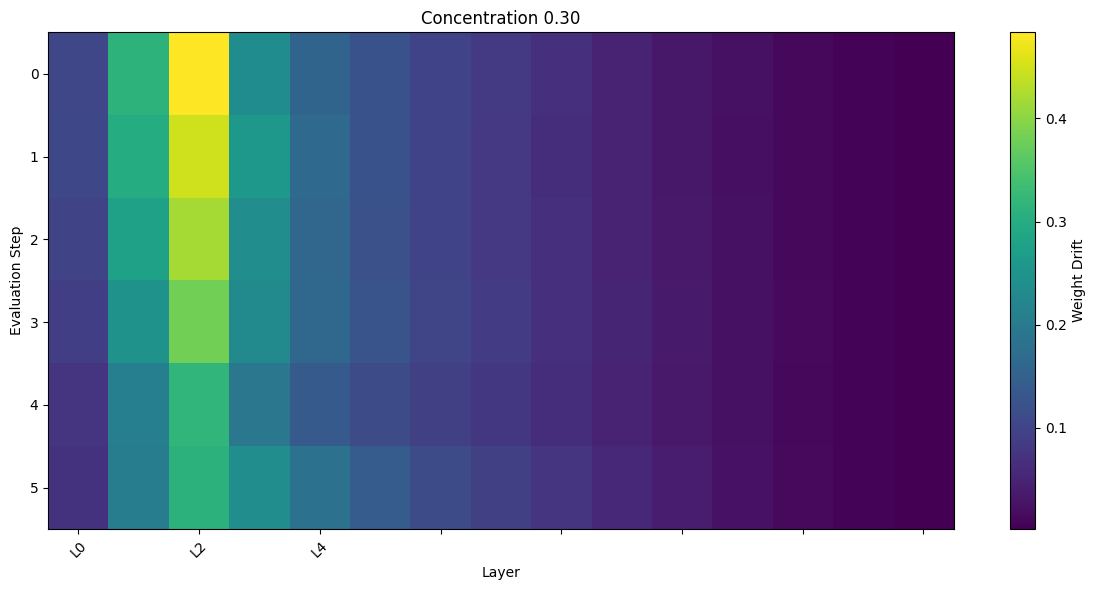

In [11]:
# show heat map of layer drift over time for each layer
plt.figure(figsize=(12, 6))
for conc_idx, concentration in enumerate(CONCENTRATIONS):
    history = all_histories[concentration]
    drift_data = np.array(history["weight_drift"])
    plt.subplot(1, len(CONCENTRATIONS), conc_idx + 1)
    plt.imshow(drift_data.T, aspect="auto", cmap=cm.viridis)
    plt.colorbar(label="Weight Drift")
    plt.title(f"Concentration {concentration:.2f}")
    plt.xlabel("Layer")
    plt.ylabel("Evaluation Step")
    plt.xticks(ticks=np.arange(len(layer_labels)), labels=layer_labels, rotation=45)
    plt.gca().xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
plt.tight_layout()
plt.show()

/tmp/ipykernel_6858/3493155590.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap   = cm.get_cmap("plasma", len(CONCENTRATIONS))
/tmp/ipykernel_6858/3493155590.py:31: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


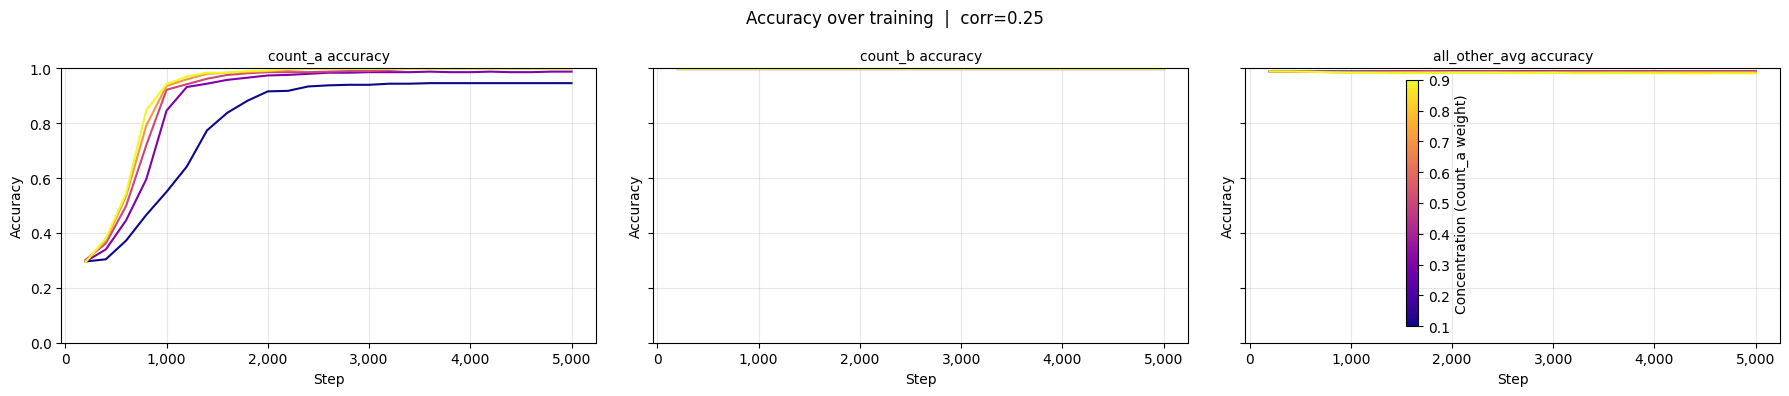

In [16]:
# One column per task group, one line per concentration, coloured by concentration
SPLIT_NAMES  = ["count_a", "count_b", "all_other_avg"]
SPLIT_TITLES = ["count_a accuracy", "count_b accuracy", "all_other_avg accuracy"]

cmap   = cm.get_cmap("plasma", len(CONCENTRATIONS))
colors = [cmap(i) for i in range(len(CONCENTRATIONS))]

fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharey=True)

for ax, split, title in zip(axes, SPLIT_NAMES, SPLIT_TITLES):
    for color, (conc, hist) in zip(colors, all_histories.items()):
        steps = hist["steps"]
        vals  = hist["val"][split]["answer_acc"]
        ax.plot(steps, vals, color=color, lw=1.5, label=f"{conc:.2f}")

    ax.set_title(title, fontsize=10)
    ax.set_xlabel("Step")
    ax.set_ylabel("Accuracy")
    ax.set_ylim(0, 1)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
    ax.grid(True, alpha=0.3)

# Shared colorbar as legend
sm = plt.cm.ScalarMappable(cmap="plasma",
                            norm=plt.Normalize(min(CONCENTRATIONS),
                                               max(CONCENTRATIONS)))
sm.set_array([])
fig.colorbar(sm, ax=axes, label="Concentration (count_a weight)", shrink=0.8, pad=0.02)

fig.suptitle(f"Accuracy over training  |  corr={CORRELATION:.2f}", fontsize=12)
plt.tight_layout()
plt.show()

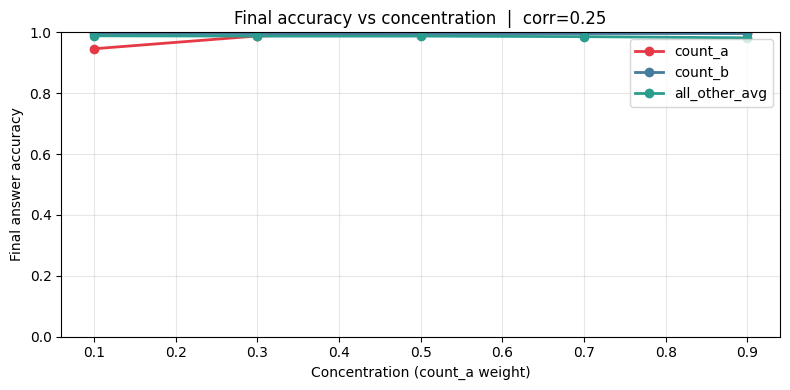

In [17]:
# Bar / line chart: final val accuracy for each split as a function of concentration
fig, ax = plt.subplots(figsize=(8, 4))

final_accs = {split: [] for split in SPLIT_NAMES}
for conc, hist in all_histories.items():
    for split in SPLIT_NAMES:
        vals = hist["val"][split]["answer_acc"]
        final_accs[split].append(vals[-1] if vals else float("nan"))

line_colors = {"count_a": "#e63946", "count_b": "#457b9d", "all_other_avg": "#2a9d8f"}
for split in SPLIT_NAMES:
    ax.plot(CONCENTRATIONS, final_accs[split],
            marker="o", lw=2, color=line_colors[split], label=split)

ax.set_xlabel("Concentration (count_a weight)")
ax.set_ylabel("Final answer accuracy")
ax.set_title(f"Final accuracy vs concentration  |  corr={CORRELATION:.2f}")
ax.set_ylim(0, 1)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

/tmp/ipykernel_6858/3145666330.py:31: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


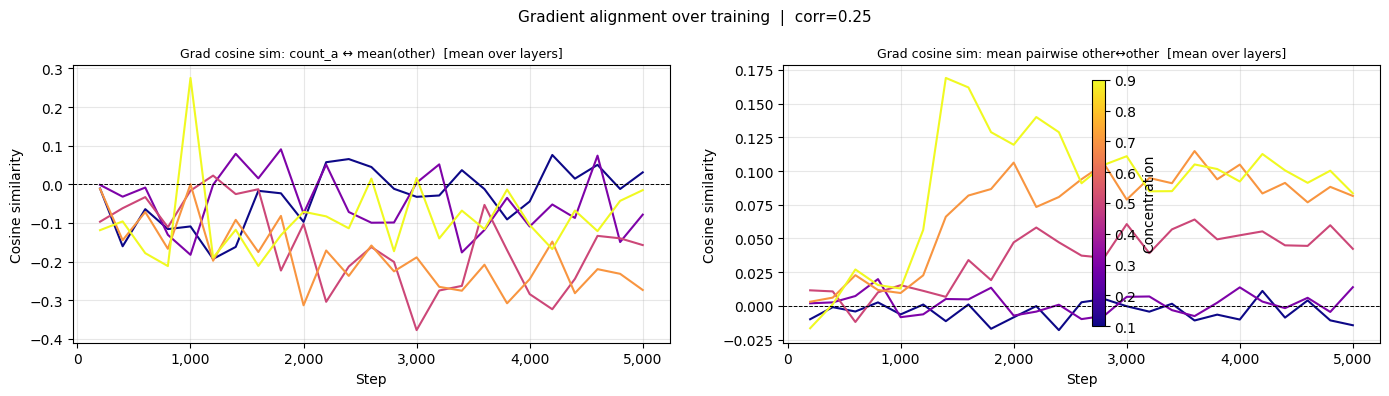

In [18]:
# Mean-across-layers gradient metrics over training steps, one line per concentration
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

titles = [
    f"Grad cosine sim: {SPECIAL_TASK} ↔ mean(other)  [mean over layers]",
    "Grad cosine sim: mean pairwise other↔other  [mean over layers]",
]
keys = ["grad_cossim_special_vs_other", "grad_cossim_other_vs_other"]

for ax, key, title in zip(axes, keys, titles):
    for color, (conc, hist) in zip(colors, all_histories.items()):
        steps = hist["steps"]
        # Each entry is a list of per-layer values → take nanmean across layers
        mean_vals = [np.nanmean(row) for row in hist[key]]
        ax.plot(steps, mean_vals, color=color, lw=1.5, label=f"{conc:.2f}")

    ax.axhline(0, color="black", lw=0.7, ls="--")
    ax.set_title(title, fontsize=9)
    ax.set_xlabel("Step")
    ax.set_ylabel("Cosine similarity")
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
    ax.grid(True, alpha=0.3)

sm = plt.cm.ScalarMappable(cmap="plasma",
                            norm=plt.Normalize(min(CONCENTRATIONS),
                                               max(CONCENTRATIONS)))
sm.set_array([])
fig.colorbar(sm, ax=axes, label="Concentration", shrink=0.8, pad=0.02)

fig.suptitle(f"Gradient alignment over training  |  corr={CORRELATION:.2f}", fontsize=11)
plt.tight_layout()
plt.show()

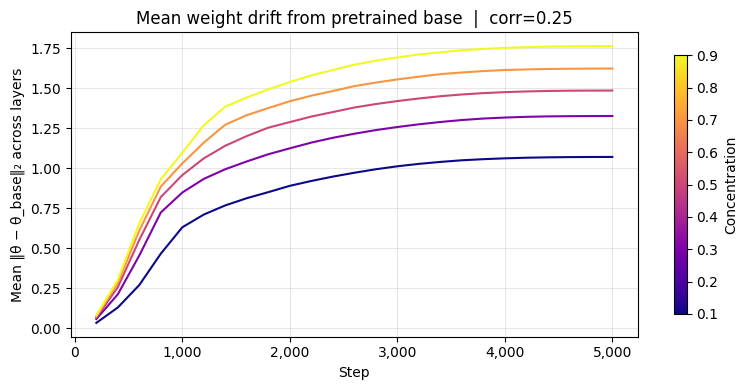

In [19]:
fig, ax = plt.subplots(figsize=(8, 4))

for color, (conc, hist) in zip(colors, all_histories.items()):
    steps     = hist["steps"]
    mean_drift = [np.nanmean(row) for row in hist["weight_drift"]]
    ax.plot(steps, mean_drift, color=color, lw=1.5, label=f"{conc:.2f}")

ax.set_title(f"Mean weight drift from last eval step  |  corr={CORRELATION:.2f}")
ax.set_xlabel("Step")
ax.set_ylabel("Mean ‖θ − θ_last_eval‖₂ across layers")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.grid(True, alpha=0.3)

sm = plt.cm.ScalarMappable(cmap="plasma",
                            norm=plt.Normalize(min(CONCENTRATIONS),
                                               max(CONCENTRATIONS)))
sm.set_array([])
fig.colorbar(sm, ax=ax, label="Concentration", shrink=0.85)

plt.tight_layout()
plt.show()